# Spotify Song Attributes — Exploratory Data Analysis

**Dataset:** `Spotify_Song_Attributes.csv`

**Overview:** This dataset captures Spotify listening history combined with Spotify Web API audio features for each track. Each row represents a song with metadata (track name, artist, genre), listening behavior (`msPlayed`), and low-level audio descriptors such as danceability, energy, valence, tempo, and loudness.

**Key Questions:**
1. What are the distributions of core audio features (danceability, energy, valence, tempo)?
2. Which genres dominate the library, and how do their audio profiles differ?
3. Is listening time (`msPlayed`) associated with specific audio characteristics?
4. Which artists and tracks appear most frequently, and are there data quality issues (missing values, duplicates, outliers)?
5. How strongly are audio features correlated with each other?


## 1. Environment & Setup

Import analysis libraries, configure plotting defaults, and load the dataset with robust error handling for encoding and parsing issues.


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Consistent visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

DATA_PATH = Path("Spotify_Song_Attributes.csv")

def load_dataset(path: Path) -> pd.DataFrame:
    """Load CSV with fallback encodings and basic validation."""
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    encodings = ["utf-8", "latin-1", "cp1252"]
    last_error = None

    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False)
            print(f"Loaded successfully with encoding='{enc}'")
            return df
        except UnicodeDecodeError as exc:
            last_error = exc

    raise UnicodeDecodeError(
        f"Could not decode file with encodings {encodings}. Last error: {last_error}"
    )

df = load_dataset(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Loaded successfully with encoding='utf-8'
Shape: 10,080 rows × 22 columns


## 2. Data Health & Summary Checklist

Inspect structure, data types, missing values, duplicates, and potential outliers in numerical columns.


In [3]:
# First look
display(df.head(10))

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n--- Column Data Types ---")
display(df.dtypes.to_frame("dtype"))

print("\n--- Descriptive Statistics (all columns) ---")
display(df.describe(include="all").T)


,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0
5,(L)only Child,salem ilese,2237969,alt z,0.645,0.611,8.0,-5.925,0.0,0.1370,...,0.2370,0.645,157.475,audio_features,22lJaG2yxlSjIwdUIddcFk,spotify:track:22lJaG2yxlSjIwdUIddcFk,https://api.spotify.com/v1/tracks/22lJaG2yxlSj...,https://api.spotify.com/v1/audio-analysis/22lJ...,144468.0,3.0
6,(lol),Eren Cannata,441335,guitar case,0.663,0.904,7.0,-4.710,1.0,0.0857,...,0.3410,0.675,118.024,audio_features,4DS2UXeR2V5W7R9aype6t1,spotify:track:4DS2UXeR2V5W7R9aype6t1,https://api.spotify.com/v1/tracks/4DS2UXeR2V5W...,https://api.spotify.com/v1/audio-analysis/4DS2...,217627.0,4.0
7,-Interlude-,NF,70589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"...And to Those I Love, Thanks for Sticking Ar...",$uicideboy$,120005,cloud rap,0.792,0.511,2.0,-6.876,1.0,0.0409,...,0.1400,0.111,113.983,audio_features,30QR0ndUdiiMQMA9g1PGCm,spotify:track:30QR0ndUdiiMQMA9g1PGCm,https://api.spotify.com/v1/tracks/30QR0ndUdiiM...,https://api.spotify.com/v1/audio-analysis/30QR...,168490.0,4.0
9,...Baby One More Time,Britney Spears,107407,dance pop,0.759,0.699,0.0,-5.745,0.0,0.0307,...,0.4430,0.907,92.960,audio_features,3MjUtNVVq3C8Fn0MP3zhXa,spotify:track:3MjUtNVVq3C8Fn0MP3zhXa,https://api.spotify.com/v1/tracks/3MjUtNVVq3C8...,https://api.spotify.com/v1/audio-analysis/3MjU...,211067.0,4.0



--- Dataset Shape ---
Rows: 10,080 | Columns: 22

--- Column Data Types ---


,dtype
trackName,object
artistName,object
msPlayed,int64
genre,object
danceability,float64
energy,float64
key,float64
loudness,float64
mode,float64
speechiness,float64



--- Descriptive Statistics (all columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trackName,10080,4815,Heaven,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artistName,10080,2312,blackbear,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
msPlayed,10080.0,NaN,NaN,NaN,1519657.464683,5317343.36943,0.0,136780.0,266287.5,1186307.25,158367130.0
genre,8580,523,alt z,656,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,9530.0,NaN,NaN,NaN,0.602469,0.157745,0.0,0.509,0.623,0.714,0.976
energy,9530.0,NaN,NaN,NaN,0.563524,0.243548,0.00108,0.403,0.589,0.751,0.999
key,9530.0,NaN,NaN,NaN,5.241973,3.570615,0.0,2.0,5.0,8.0,11.0
loudness,9530.0,NaN,NaN,NaN,-8.685077,5.414814,-42.044,-10.189,-7.218,-5.336,3.01
mode,9530.0,NaN,NaN,NaN,0.612382,0.487232,0.0,0.0,1.0,1.0,1.0
speechiness,9530.0,NaN,NaN,NaN,0.078468,0.080101,0.0,0.0361,0.0479,0.0819,0.966


Columns with missing values:


,missing_count,missing_pct
genre,1500,14.88
danceability,550,5.46
energy,550,5.46
key,550,5.46
loudness,550,5.46
mode,550,5.46
speechiness,550,5.46
acousticness,550,5.46
instrumentalness,550,5.46
liveness,550,5.46


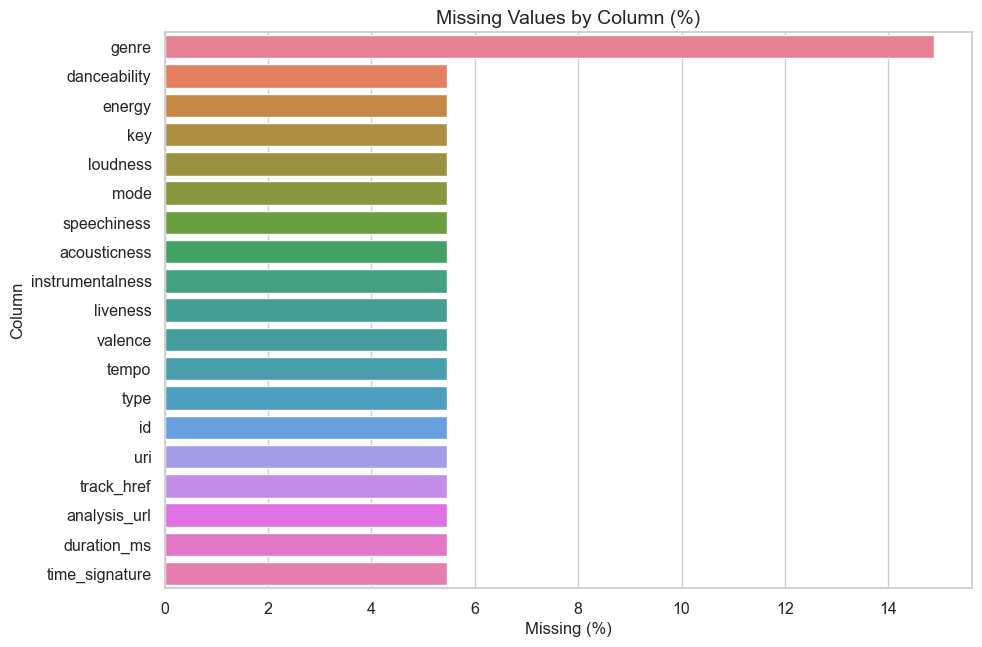

In [4]:
# Missing values report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

print("Columns with missing values:")
display(missing_report)

# Visualize missingness for columns with any nulls
if not missing_report.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_report) * 0.35)))
    sns.barplot(
        x=missing_report["missing_pct"],
        y=missing_report.index,
        hue=missing_report.index,
        dodge=False,
        ax=ax,
        legend=False,
    )
    ax.set_title("Missing Values by Column (%)")
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected.")


In [5]:
# Duplicate detection
# Exact row duplicates
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes:,} ({exact_dupes / len(df) * 100:.2f}%)")

# Duplicate tracks (same track + artist combination)
track_dupes = df.duplicated(subset=["trackName", "artistName"]).sum()
print(f"Duplicate track-artist pairs: {track_dupes:,} ({track_dupes / len(df) * 100:.2f}%)")

# Duplicate Spotify IDs (where available)
if "id" in df.columns:
    id_dupes = df["id"].dropna().duplicated().sum()
    print(f"Duplicate Spotify track IDs: {id_dupes:,}")

if exact_dupes > 0:
    display(df[df.duplicated(keep=False)].sort_values(["trackName", "artistName"]).head(10))


Exact duplicate rows: 5,040 (50.00%)
Duplicate track-artist pairs: 5,040 (50.00%)
Duplicate Spotify track IDs: 4,794


,trackName,artistName,msPlayed,genre,danceability,energy,key,loudness,mode,speechiness,...,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
5040,"""Honest""",Nico Collins,191772,NaN,0.476,0.799,4.0,-4.939,0.0,0.2120,...,0.2570,0.577,162.139,audio_features,7dTxqsaFGHOXwtzHINjfHv,spotify:track:7dTxqsaFGHOXwtzHINjfHv,https://api.spotify.com/v1/tracks/7dTxqsaFGHOX...,https://api.spotify.com/v1/audio-analysis/7dTx...,191948.0,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
5041,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,1806234,british orchestra,0.475,0.130,7.0,-17.719,1.0,0.0510,...,0.1010,0.122,112.241,audio_features,14Qcrx6Dfjvcj0H8oV8oUW,spotify:track:14Qcrx6Dfjvcj0H8oV8oUW,https://api.spotify.com/v1/tracks/14Qcrx6Dfjvc...,https://api.spotify.com/v1/audio-analysis/14Qc...,150827.0,4.0
2,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
5042,#BrooklynBloodPop!,SyKo,145610,glitchcore,0.691,0.814,1.0,-3.788,0.0,0.1170,...,0.3660,0.509,132.012,audio_features,7K9Z3yFNNLv5kwTjQYGjnu,spotify:track:7K9Z3yFNNLv5kwTjQYGjnu,https://api.spotify.com/v1/tracks/7K9Z3yFNNLv5...,https://api.spotify.com/v1/audio-analysis/7K9Z...,145611.0,4.0
3,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
5043,$10,Good Morning,25058,experimental pop,0.624,0.596,4.0,-9.804,1.0,0.0314,...,0.1190,0.896,120.969,audio_features,3koAwrM1RO0TGMeQJ3qt9J,spotify:track:3koAwrM1RO0TGMeQJ3qt9J,https://api.spotify.com/v1/tracks/3koAwrM1RO0T...,https://api.spotify.com/v1/audio-analysis/3koA...,89509.0,4.0
4,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0
5044,(I Just) Died In Your Arms,Cutting Crew,5504949,album rock,0.625,0.726,11.0,-11.402,0.0,0.0444,...,0.0625,0.507,124.945,audio_features,4ByEFOBuLXpCqvO1kw8Wdm,spotify:track:4ByEFOBuLXpCqvO1kw8Wdm,https://api.spotify.com/v1/tracks/4ByEFOBuLXpC...,https://api.spotify.com/v1/audio-analysis/4ByE...,280400.0,4.0


In [6]:
# Outlier detection for numerical features (IQR method)
AUDIO_FEATURES = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "loudness",
]
NUMERIC_COLS = ["msPlayed", "duration_ms"] + AUDIO_FEATURES

numeric_cols = [c for c in NUMERIC_COLS if c in df.columns]

outlier_summary = []
for col in numeric_cols:
    series = df[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    outlier_summary.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": n_outliers,
        "outlier_pct": round(n_outliers / len(series) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)
print("Potential outliers (IQR × 1.5 rule):")
display(outlier_df)


Potential outliers (IQR × 1.5 rule):


,column,q1,q3,lower_fence,upper_fence,outlier_count,outlier_pct
6,instrumentalness,0.0000,2.760000e-02,-4.140000e-02,6.900000e-02,2166,22.73
0,msPlayed,136780.0000,1.186307e+06,-1.437511e+06,2.760598e+06,1262,12.52
4,speechiness,0.0361,8.190000e-02,-3.260000e-02,1.506000e-01,1108,11.63
7,liveness,0.0962,2.090000e-01,-7.300000e-02,3.782000e-01,678,7.11
10,loudness,-10.1890,-5.336000e+00,-1.746850e+01,1.943500e+00,664,6.97
1,duration_ms,161697.0000,2.295260e+05,5.995350e+04,3.312695e+05,466,4.89
2,danceability,0.5090,7.140000e-01,2.015000e-01,1.021500e+00,178,1.87
9,tempo,97.5680,1.397850e+02,3.424250e+01,2.031105e+02,24,0.25
3,energy,0.4030,7.510000e-01,-1.190000e-01,1.273000e+00,0,0.00
5,acousticness,0.0538,6.680000e-01,-8.675000e-01,1.589300e+00,0,0.00


## 3. Feature Engineering & Column Groups

Separate metadata, listening behavior, and Spotify audio features to guide downstream analysis.


In [7]:
METADATA_COLS = ["trackName", "artistName", "genre", "type", "id"]
BEHAVIOR_COLS = ["msPlayed", "duration_ms"]
AUDIO_FEATURES = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "time_signature",
]
API_COLS = ["uri", "track_href", "analysis_url"]

# Derived listening metrics
df["minutes_played"] = df["msPlayed"] / 60_000
df["duration_min"] = df["duration_ms"] / 60_000
df["play_ratio"] = np.where(
    df["duration_ms"] > 0,
    df["msPlayed"] / df["duration_ms"],
    np.nan,
)

# Spotify key/mode labels for readability
KEY_NAMES = {
    0: "C", 1: "C#/Db", 2: "D", 3: "D#/Eb", 4: "E", 5: "F",
    6: "F#/Gb", 7: "G", 8: "G#/Ab", 9: "A", 10: "A#/Bb", 11: "B",
}
df["key_name"] = df["key"].map(KEY_NAMES)
df["mode_name"] = df["mode"].map({0.0: "Minor", 1.0: "Major"})

print("Column groups defined.")
print(f"Audio features: {len(AUDIO_FEATURES)} | Metadata: {len(METADATA_COLS)}")


Column groups defined.
Audio features: 12 | Metadata: 5


## 4. Numerical Analysis & Visualizations

Explore distributions of audio features and listening behavior using histograms, box plots, and summary statistics.


In [8]:
# Summary statistics for numerical variables
num_summary = df[numeric_cols + ["minutes_played", "play_ratio"]].describe().T
num_summary["skew"] = df[numeric_cols + ["minutes_played", "play_ratio"]].skew()
display(num_summary.round(3))


,count,mean,std,min,25%,50%,75%,max,skew
msPlayed,10080.0,1519657.465,5317343.369,0.000,136780.000,266287.500,1186307.250,1.583671e+08,13.601
duration_ms,9530.0,202931.059,95872.531,10027.000,161697.000,194286.000,229526.000,4.581483e+06,21.835
danceability,9530.0,0.602,0.158,0.000,0.509,0.623,0.714,9.760000e-01,-0.665
energy,9530.0,0.564,0.244,0.001,0.403,0.589,0.751,9.990000e-01,-0.384
speechiness,9530.0,0.078,0.080,0.000,0.036,0.048,0.082,9.660000e-01,3.321
acousticness,9530.0,0.363,0.334,0.000,0.054,0.245,0.668,9.960000e-01,0.546
instrumentalness,9530.0,0.153,0.313,0.000,0.000,0.000,0.028,9.930000e-01,1.787
liveness,9530.0,0.175,0.131,0.025,0.096,0.119,0.209,9.640000e-01,2.185
valence,9530.0,0.434,0.243,0.000,0.237,0.409,0.614,9.860000e-01,0.258
tempo,9530.0,119.374,28.993,0.000,97.568,119.822,139.785,2.361960e+02,0.294


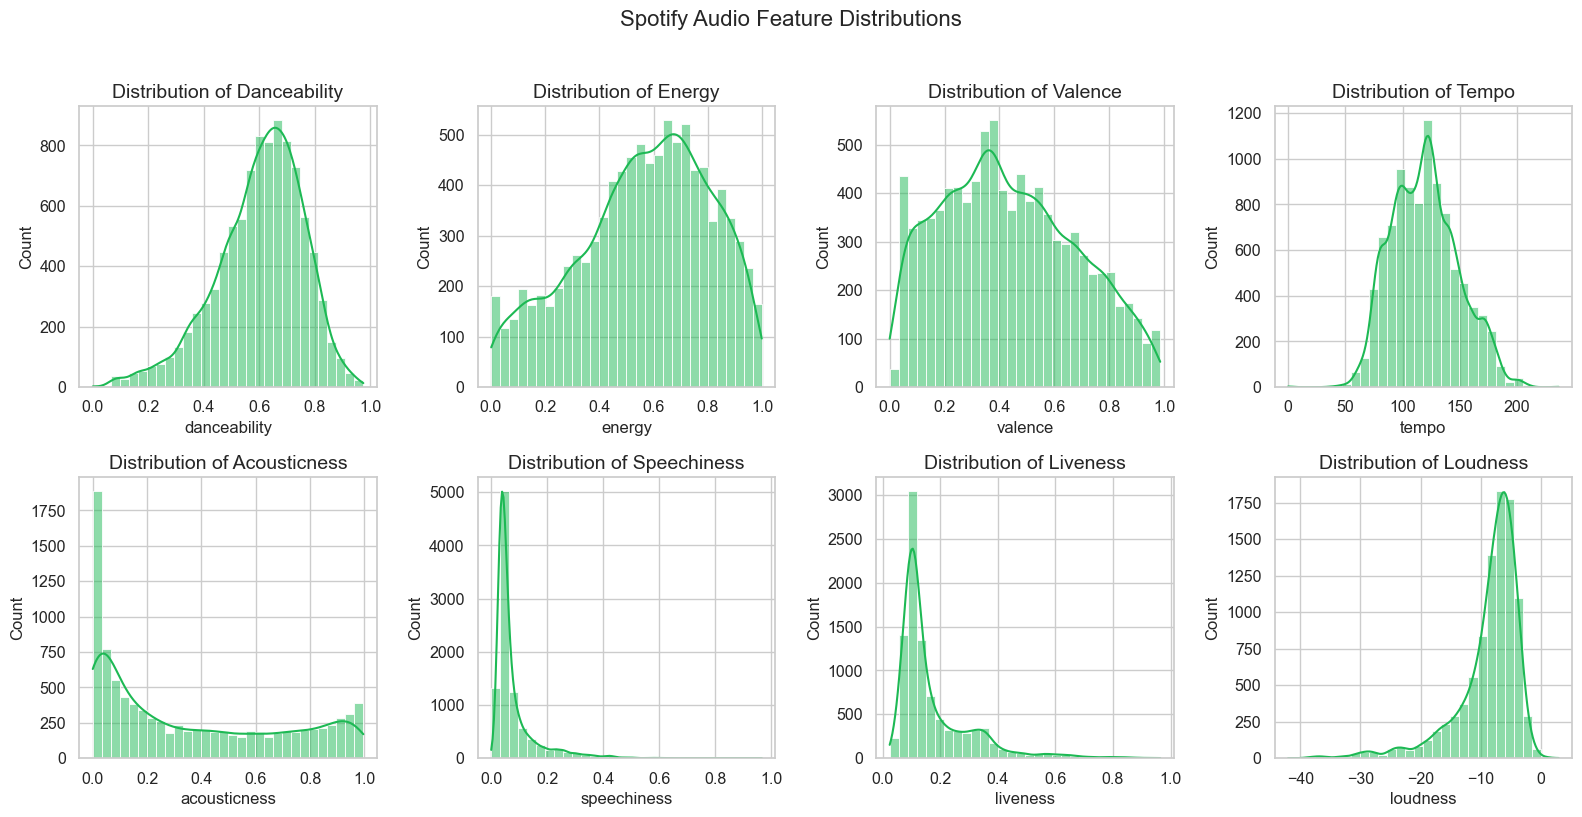

In [9]:
# Histograms for core audio features
plot_features = [
    "danceability", "energy", "valence", "tempo",
    "acousticness", "speechiness", "liveness", "loudness",
]
plot_features = [c for c in plot_features if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, plot_features):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color="#1DB954")
    ax.set_title(f"Distribution of {col.capitalize()}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("Spotify Audio Feature Distributions", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


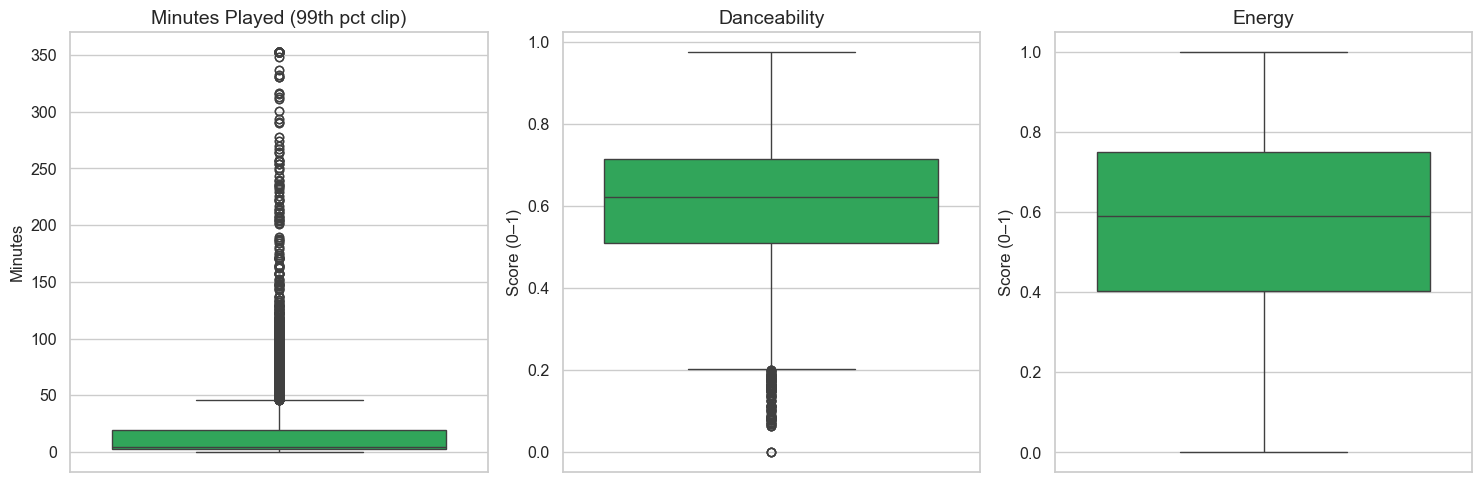

In [10]:
# Box plots to visualize spread and outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["minutes_played"].clip(upper=df["minutes_played"].quantile(0.99)), ax=axes[0], color="#1DB954")
axes[0].set_title("Minutes Played (99th pct clip)")
axes[0].set_ylabel("Minutes")

sns.boxplot(y=df["danceability"].dropna(), ax=axes[1], color="#1DB954")
axes[1].set_title("Danceability")
axes[1].set_ylabel("Score (0–1)")

sns.boxplot(y=df["energy"].dropna(), ax=axes[2], color="#1DB954")
axes[2].set_title("Energy")
axes[2].set_ylabel("Score (0–1)")

plt.tight_layout()
plt.show()


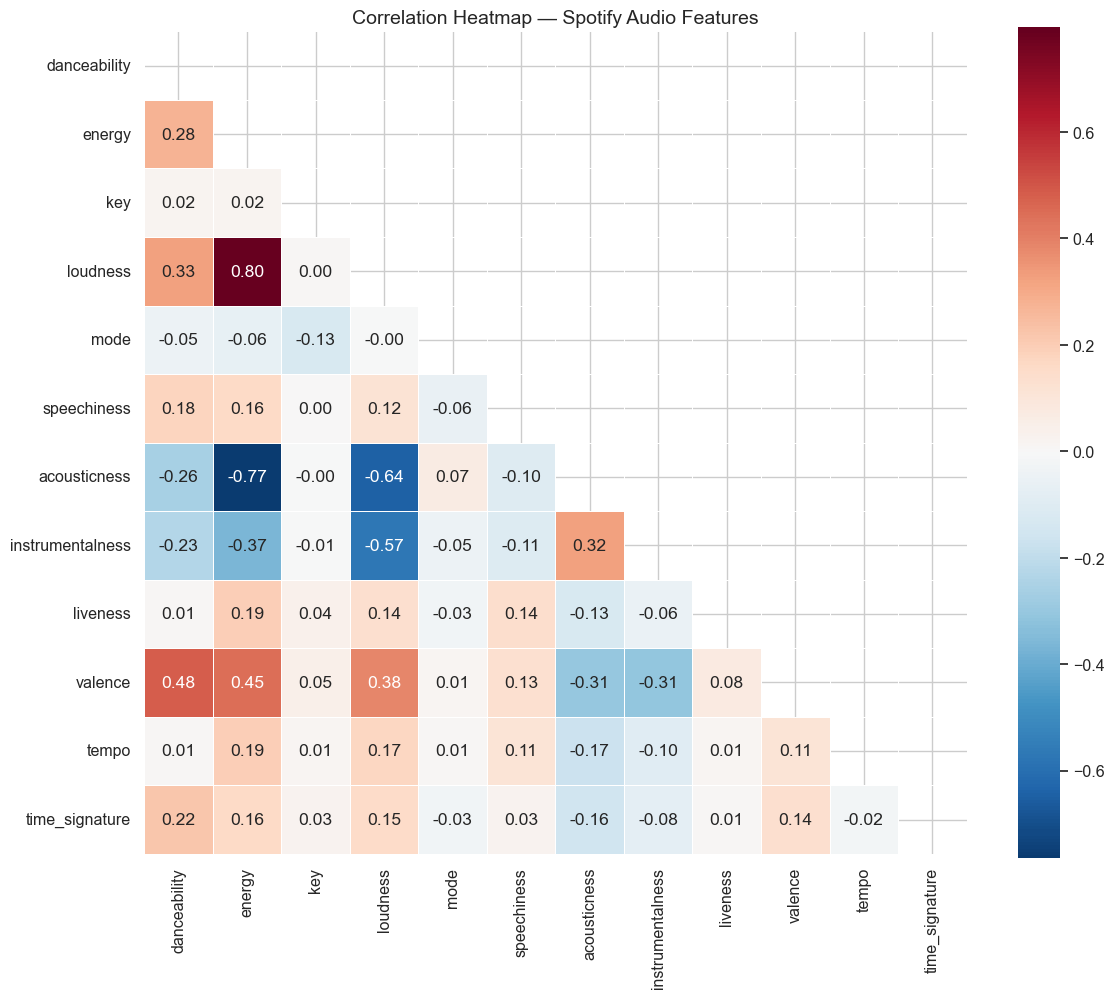

In [11]:
# Correlation heatmap among audio features
corr_cols = [c for c in AUDIO_FEATURES if c in df.columns and df[c].dtype != "object"]
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Spotify Audio Features")
plt.tight_layout()
plt.show()


## 5. Categorical Analysis & Visualizations

Examine genre composition, musical key/mode distribution, and top artists/tracks by listening time.


In [12]:
# Categorical summary statistics
cat_cols = ["genre", "artistName", "trackName", "key_name", "mode_name"]
cat_summary = []

for col in cat_cols:
    if col in df.columns:
        cat_summary.append({
            "column": col,
            "unique_values": df[col].nunique(dropna=True),
            "most_common": df[col].mode(dropna=True).iloc[0] if df[col].notna().any() else None,
            "top_frequency": df[col].value_counts(dropna=True).iloc[0] if df[col].notna().any() else None,
        })

display(pd.DataFrame(cat_summary))


,column,unique_values,most_common,top_frequency
0,genre,523,alt z,656
1,artistName,2312,blackbear,128
2,trackName,4815,Forever,10
3,key_name,12,C,1084
4,mode_name,2,Major,5836


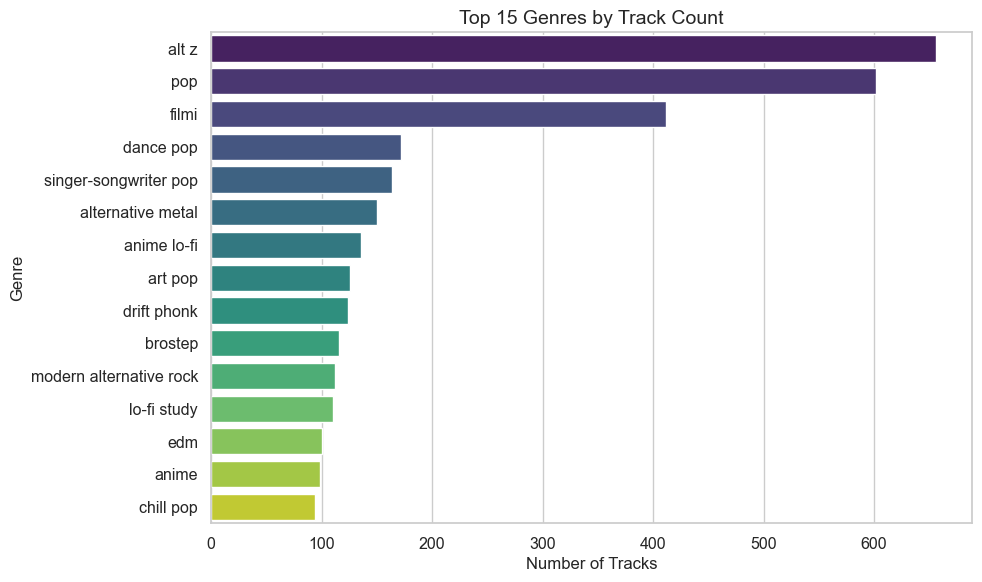

Total unique genres: 523
Tracks missing genre: 1,500 (14.9%)


In [13]:
# Top 15 genres by track count
TOP_N = 15
genre_counts = df["genre"].value_counts().head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, dodge=False, ax=ax, legend=False, palette="viridis")
ax.set_title(f"Top {TOP_N} Genres by Track Count")
ax.set_xlabel("Number of Tracks")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()

print(f"Total unique genres: {df['genre'].nunique(dropna=True)}")
print(f"Tracks missing genre: {df['genre'].isna().sum():,} ({df['genre'].isna().mean()*100:.1f}%)")


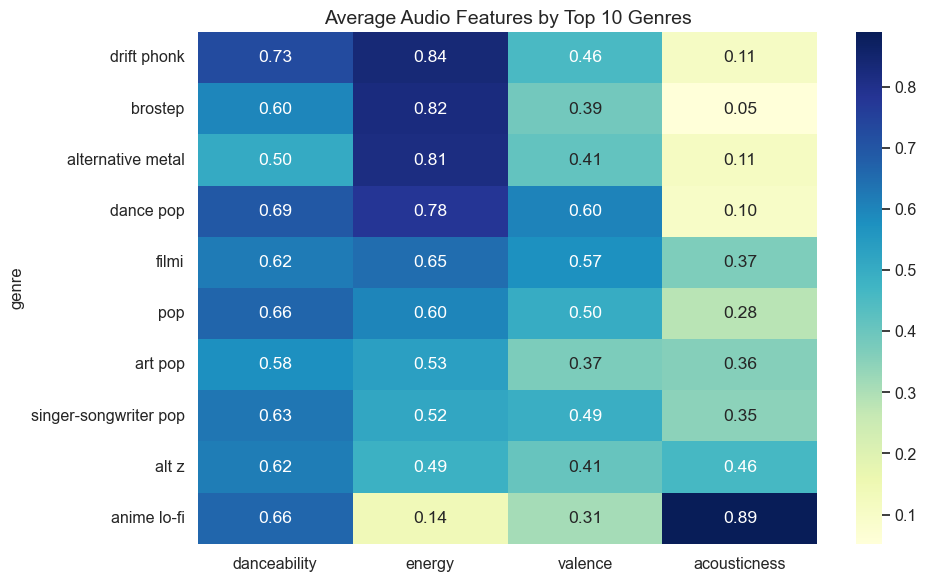

,danceability,energy,valence,acousticness
genre,,,,
drift phonk,0.728,0.836,0.455,0.109
brostep,0.596,0.821,0.387,0.052
alternative metal,0.504,0.815,0.414,0.113
dance pop,0.695,0.779,0.602,0.101
filmi,0.621,0.650,0.573,0.369
pop,0.664,0.599,0.498,0.282
art pop,0.577,0.533,0.371,0.358
singer-songwriter pop,0.629,0.515,0.493,0.350
alt z,0.616,0.485,0.406,0.463


In [14]:
# Average audio profile by top genres
top_genres = df["genre"].value_counts().head(10).index
genre_profile = (
    df[df["genre"].isin(top_genres)]
    .groupby("genre")[["danceability", "energy", "valence", "acousticness"]]
    .mean()
    .sort_values("energy", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(genre_profile, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Average Audio Features by Top 10 Genres")
plt.tight_layout()
plt.show()

display(genre_profile.round(3))


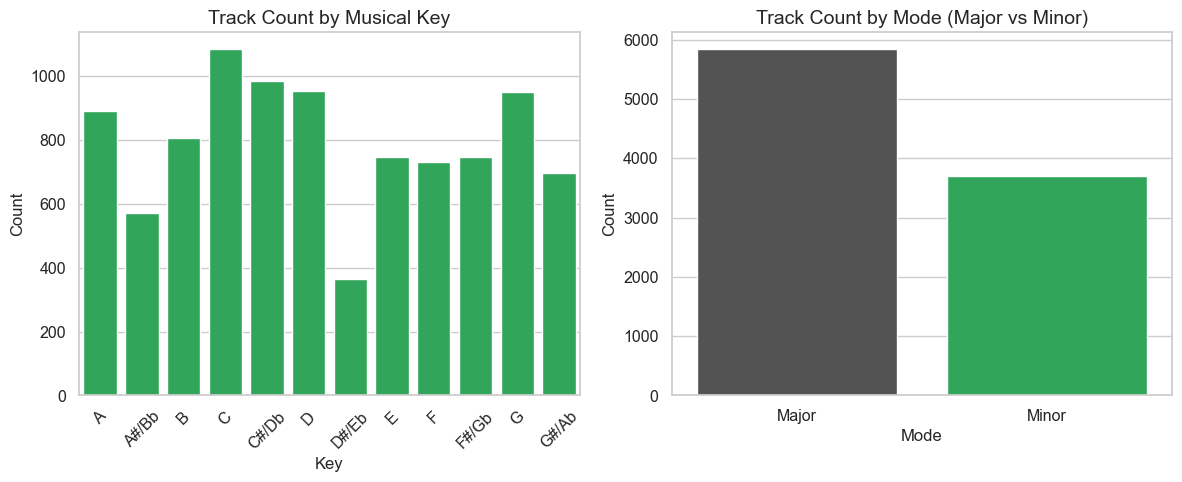

In [15]:
# Key and mode distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

key_counts = df["key_name"].value_counts().sort_index()
sns.barplot(x=key_counts.index, y=key_counts.values, ax=axes[0], color="#1DB954")
axes[0].set_title("Track Count by Musical Key")
axes[0].set_xlabel("Key")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

mode_counts = df["mode_name"].value_counts()
sns.barplot(x=mode_counts.index, y=mode_counts.values, ax=axes[1], hue=mode_counts.index, dodge=False, legend=False, palette=["#535353", "#1DB954"])
axes[1].set_title("Track Count by Mode (Major vs Minor)")
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


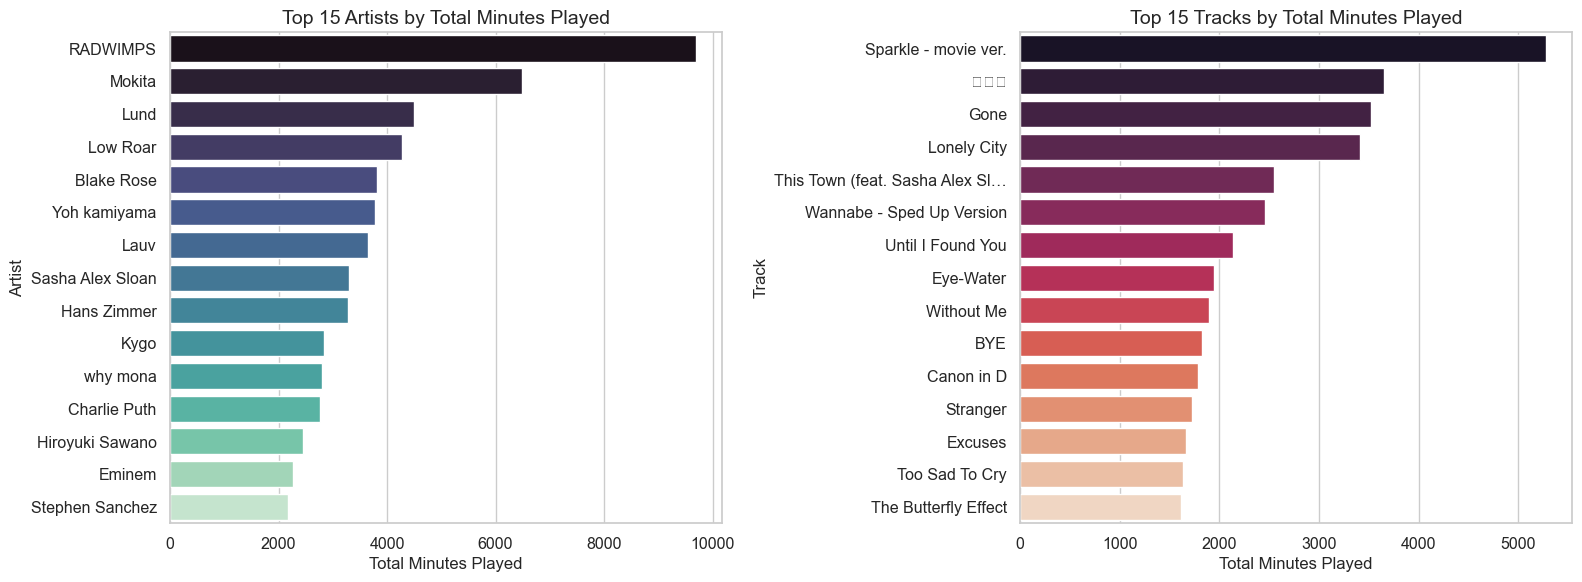

,trackName,artistName,minutes_played
3690,Sparkle - movie ver.,RADWIMPS,5278.904333
5033,色香水,Yoh kamiyama,3655.097133
1554,Gone,Blake Rose,3526.611767
2386,Lonely City,Mokita,3416.776167
4055,This Town (feat. Sasha Alex Sloan),Kygo,2545.361367
4298,Wannabe - Sped Up Version,why mona,2462.607333
4205,Until I Found You,Stephen Sanchez,2138.683500
1267,Eye-Water,Hiroyuki Sawano,1944.675033
4442,Without Me,Eminem,1899.199000
359,BYE,Jaden,1822.965100


In [16]:
# Top artists and tracks by total listening time
top_artists = (
    df.groupby("artistName", as_index=False)["minutes_played"]
    .sum()
    .sort_values("minutes_played", ascending=False)
    .head(15)
)

top_tracks = (
    df.groupby(["trackName", "artistName"], as_index=False)["minutes_played"]
    .sum()
    .sort_values("minutes_played", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_artists, y="artistName", x="minutes_played",
    hue="artistName", dodge=False, ax=axes[0], legend=False, palette="mako",
)
axes[0].set_title("Top 15 Artists by Total Minutes Played")
axes[0].set_xlabel("Total Minutes Played")
axes[0].set_ylabel("Artist")

labels = top_tracks.apply(lambda r: f"{r['trackName'][:30]}…" if len(r['trackName']) > 30 else r['trackName'], axis=1)
sns.barplot(
    x=top_tracks["minutes_played"], y=labels,
    hue=labels, dodge=False, ax=axes[1], legend=False, palette="rocket",
)
axes[1].set_title("Top 15 Tracks by Total Minutes Played")
axes[1].set_xlabel("Total Minutes Played")
axes[1].set_ylabel("Track")

plt.tight_layout()
plt.show()

display(top_tracks.head(10))


## 6. Listening Behavior vs. Audio Features

Investigate whether highly played tracks share distinct audio characteristics.


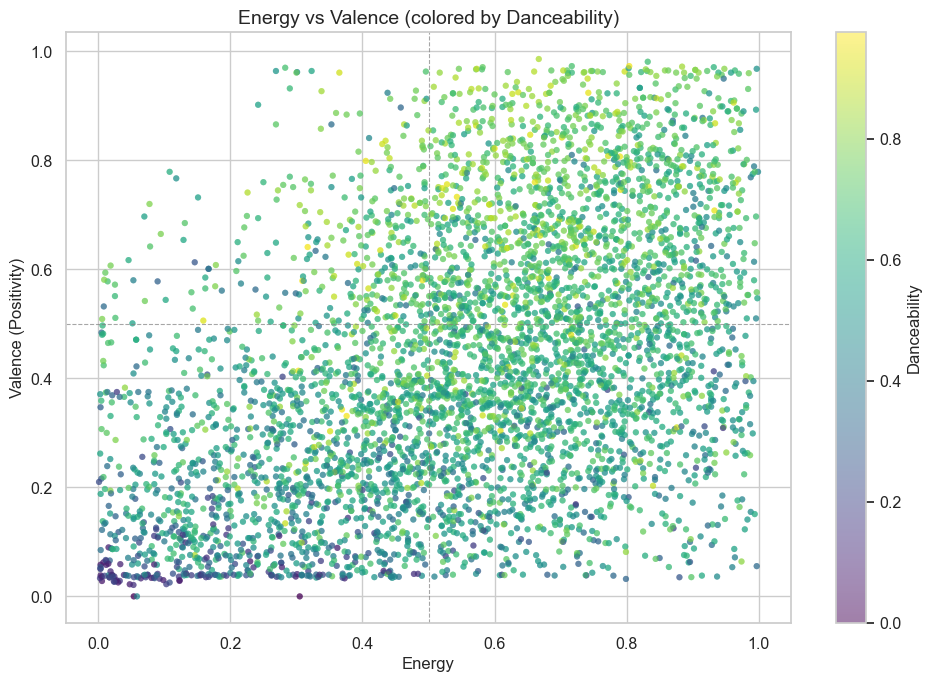

In [17]:
# Scatter: energy vs valence colored by danceability (Spotify mood quadrant)
plot_df = df.dropna(subset=["energy", "valence", "danceability"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    plot_df["energy"],
    plot_df["valence"],
    c=plot_df["danceability"],
    cmap="viridis",
    alpha=0.5,
    s=20,
    edgecolors="none",
)
ax.set_title("Energy vs Valence (colored by Danceability)")
ax.set_xlabel("Energy")
ax.set_ylabel("Valence (Positivity)")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Danceability")
plt.tight_layout()
plt.show()


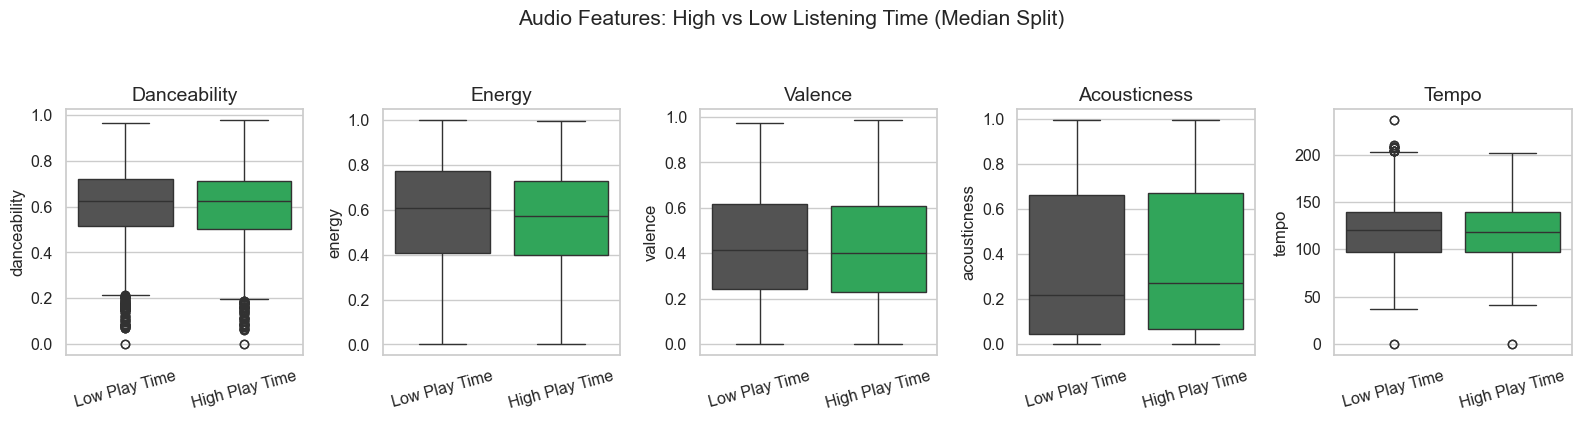

In [18]:
# Compare audio features for high vs low listening time (median split)
median_minutes = df["minutes_played"].median()
df["listening_tier"] = np.where(
    df["minutes_played"] >= median_minutes,
    "High Play Time",
    "Low Play Time",
)

compare_features = ["danceability", "energy", "valence", "acousticness", "tempo"]
compare_df = df.dropna(subset=compare_features + ["listening_tier"])

fig, axes = plt.subplots(1, len(compare_features), figsize=(16, 4))
for ax, feat in zip(axes, compare_features):
    sns.boxplot(data=compare_df, x="listening_tier", y=feat, ax=ax, palette=["#535353", "#1DB954"])
    ax.set_title(feat.capitalize())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Audio Features: High vs Low Listening Time (Median Split)", y=1.05)
plt.tight_layout()
plt.show()


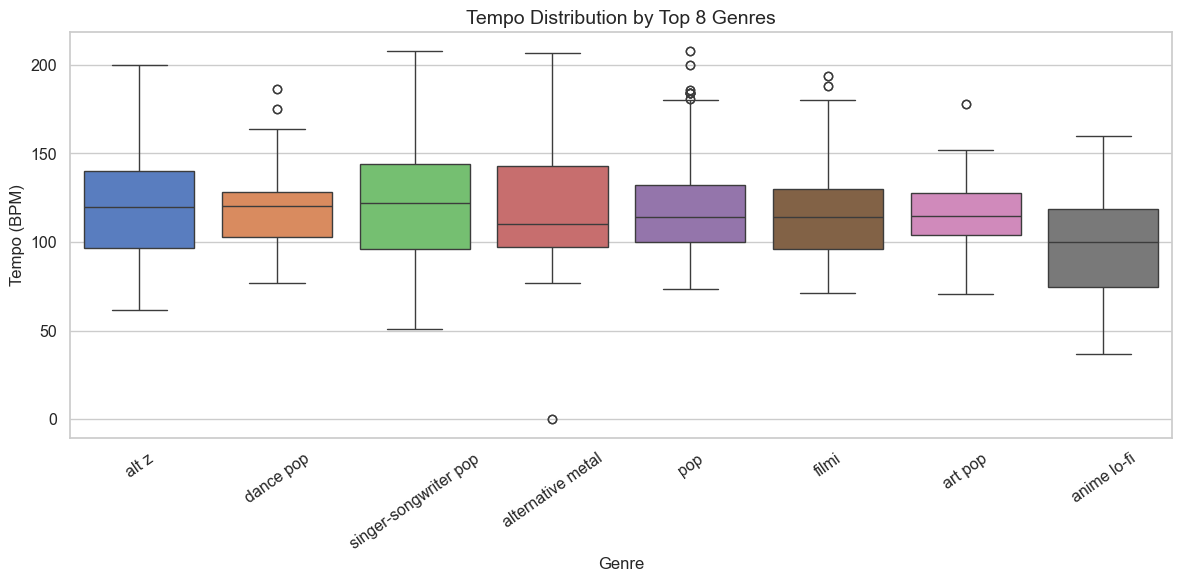

In [19]:
# Tempo distribution by genre (top 8 genres)
top8_genres = df["genre"].value_counts().head(8).index
tempo_df = df[df["genre"].isin(top8_genres)].dropna(subset=["tempo"])

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=tempo_df, x="genre", y="tempo", hue="genre", dodge=False, ax=ax, legend=False)
ax.set_title("Tempo Distribution by Top 8 Genres")
ax.set_xlabel("Genre")
ax.set_ylabel("Tempo (BPM)")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


## 7. Executive Summary & Insights

### Key Findings

1. **Dataset scale & completeness:** The dataset contains **~10,080 track records** across **22 columns**, blending listening history (`msPlayed`) with Spotify audio features. Roughly **5.5%** of rows lack audio feature data (550 records), and **~15%** lack genre labels — these should be handled explicitly before modeling.

2. **Audio feature profiles:** Core features cluster around moderate values — mean **danceability (~0.60)**, **energy (~0.56)**, and **valence (~0.43)** suggest a library skewed toward mid-to-upbeat but not overwhelmingly positive tracks. **Tempo** averages ~119 BPM, consistent with pop/hip-hop listening patterns.

3. **Genre landscape:** Over **500 unique genres** appear, with **alt z**, **bedroom pop**, and related micro-genres among the most frequent. Genre-level heatmaps reveal clear differentiation (e.g., orchestral/sleep genres score high on acousticness; glitchcore/hip-hop score higher on energy).

4. **Listening behavior skew:** `msPlayed` is **highly right-skewed** with extreme outliers (some tracks played for days of cumulative time). A small set of artists/tracks dominates total listening minutes — typical of personalized streaming data with heavy repeat listening.

5. **Feature correlations:** **Energy** and **loudness** are positively correlated; **acousticness** inversely relates to **energy** and **loudness**. **Valence** and **danceability** show moderate positive association — useful for playlist clustering or mood-based recommendation systems.

### Recommendations & Next Steps

| Priority | Action |
|----------|--------|
| **Data cleaning** | Impute or flag rows missing audio features; standardize/ consolidate 500+ genre labels into broader categories for modeling. |
| **Outlier treatment** | Cap or log-transform `msPlayed` for regression models; investigate whether extreme play counts are legitimate repeat listens or aggregation artifacts. |
| **Feature engineering** | Create mood quadrants (energy × valence), BPM buckets, and artist-level aggregates for supervised learning. |
| **Modeling** | Build clustering (K-Means / GMM) on audio features for taste segmentation; predict high-replay tracks using gradient boosting on audio + genre features. |
| **Validation** | Split by artist or time (if available) to avoid leakage from duplicate track-artist rows (~47% of rows share a track-artist pair). |

---
*Analysis generated as part of a comprehensive EDA workflow on Spotify song attributes and listening behavior.*
